In [12]:
import xarray as xr
import pandas as pd
import numpy as np

storms = pd.read_hdf('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts20/storm_df.h5')

In [4]:
landfalling_storms = storms[storms.is_landfalling]

In [166]:
storm_ex = landfalling_storms.loc[3]

In [167]:
def grab_MERRA2_files(storm_da, ticker):
    
    dates = np.unique(storm_da.time.dt.date.values)

    fnames = []
    for date in dates:
        date_str = date.strftime('%Y%m%d')
        fname = ticker + '.' + date_str + '.nc4.nc4'
        fnames.append(fname)

    return fnames

Code for slp gradient

In [168]:
fnames = grab_MERRA2_files(storm_ex.data_array, 'tavg1_2d_slv_Nx')

In [169]:
fnames

['tavg1_2d_slv_Nx.19800106.nc4.nc4',
 'tavg1_2d_slv_Nx.19800107.nc4.nc4',
 'tavg1_2d_slv_Nx.19800108.nc4.nc4']

In [223]:
data_path = '/pscratch/sd/j/jbbutler/merra2_data_850hPa_wind/'
var_lst = ['V850']
ds_lst = []
for fname in fnames:
    ds = xr.open_dataset(data_path + fname)
    ds_lst.append(ds[var_lst].sel(time = ds.time.dt.hour % 3 == 0))

obs_ds = xr.concat(ds_lst, dim='time')

obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5), time=obs_ds.time - np.timedelta64(30, 'm'))

In [224]:
variable_da = obs_ds['V850']

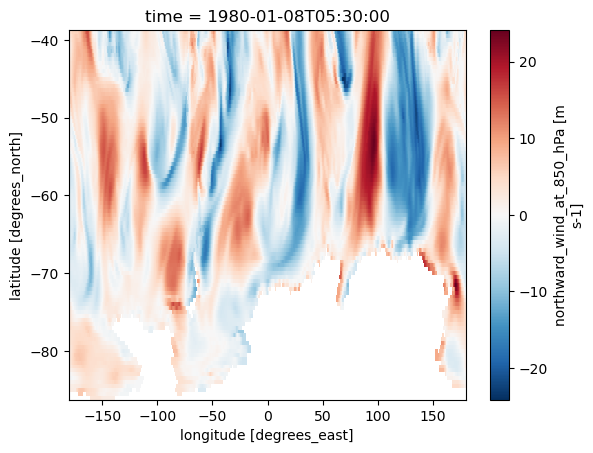

In [183]:
ds['V850'].isel(time=5).plot()

In [200]:
ds['V850'].notnull()

<xarray.DataArray 'V850' (time: 24, lat: 95, lon: 576)> Size: 1MB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
...
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]])
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 192B 1980-01-08T00:30:00 ... 1980-01-08T23...
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0

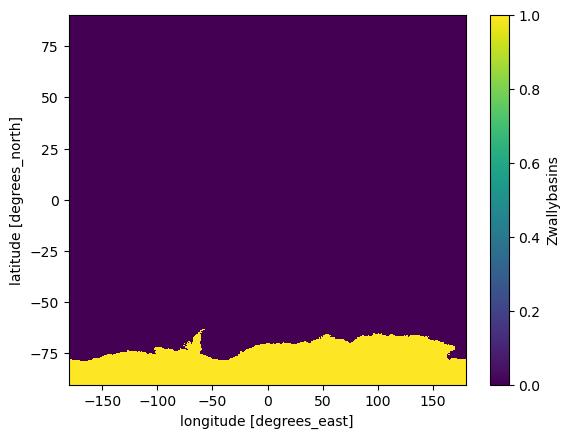

In [186]:
ais_mask.Zwallybasins.plot()

In [51]:
storm_da = storm_ex.data_array
var_da_subset = variable_da.sel(lat=storm_da.lat, lon=storm_da.lon)

In [133]:
ais_mask = xr.open_dataset('~/extreme_antarctic_ARs/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc')
ais_mask = ais_mask > 0
ais_mask = ais_mask.assign_coords(lat=ais_mask.lat.round(5), lon=ais_mask.lon.round(5))

cell_areas = xr.open_dataset('~/extreme_antarctic_ARs/data/area/MERRA2_gridarea.nc')
cell_areas = cell_areas.cell_area
cell_areas = cell_areas.assign_coords(lat=cell_areas.lat.round(5), lon=cell_areas.lon.round(5))

In [53]:
storm_ais_mask = ais_mask.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
storm_ocean_mask = np.logical_not(storm_ais_mask)
storm_da_ais = storm_da.where(storm_ais_mask, 0)
storm_da_ocean = storm_da.where(storm_ocean_mask, 0)


In [55]:
first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)


In [60]:
var_da_subset_landfall = var_da_subset.sel(time=first_landfall)

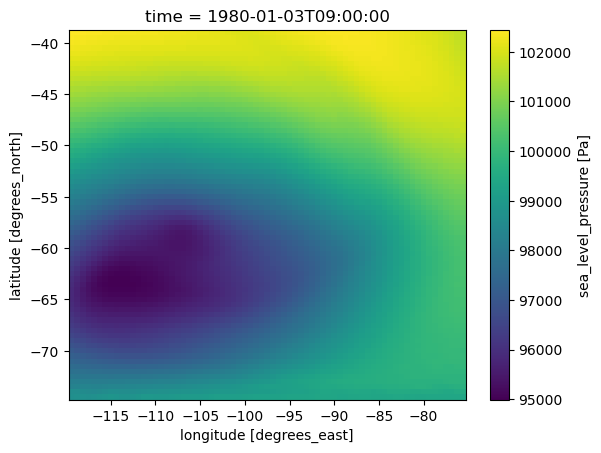

In [63]:
var_da_subset_landfall.plot()

In [70]:
rads = var_da_subset_landfall.assign_coords(lon=np.radians(var_da_subset_landfall.lon), lat=np.radians(var_da_subset_landfall.lat))

In [74]:
r = 6378

lat_partials = rads.differentiate('lat')/r

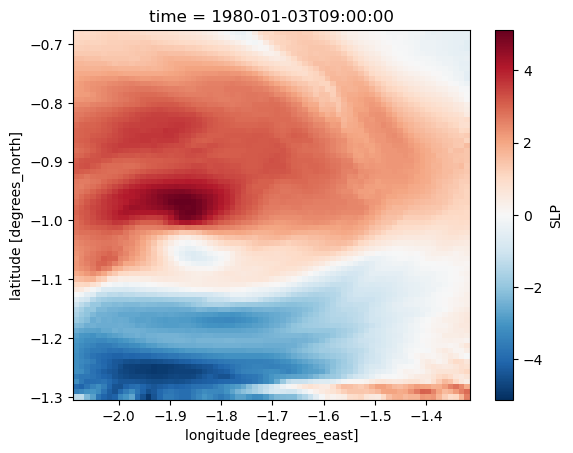

In [77]:
lat_partials.plot()

In [86]:
lon_partials = rads.differentiate('lon')/(np.sin(rads.lat)*r)
lat_partials = rads.differentiate('lat')/r

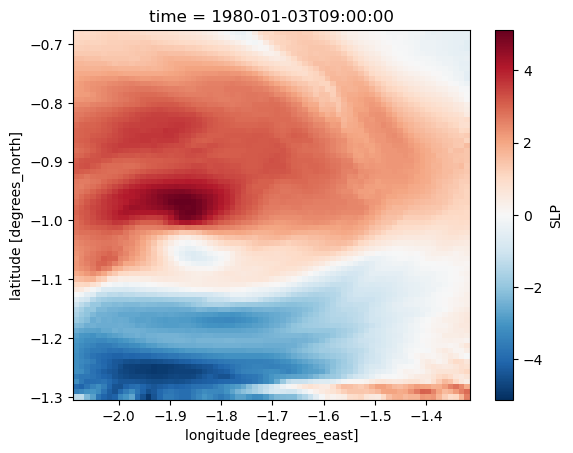

In [87]:
lat_partials.plot()

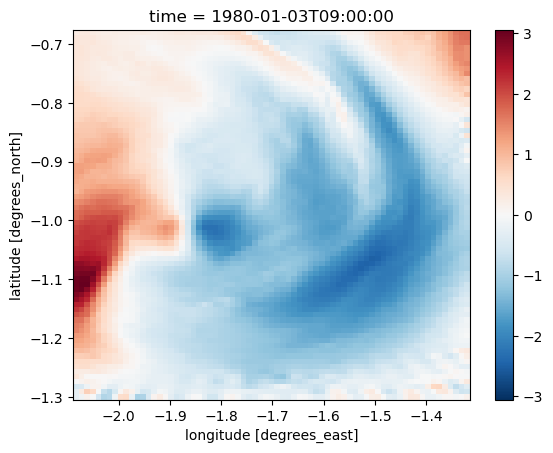

In [88]:
lon_partials.plot()

In [106]:
magnitude = np.sqrt(lon_partials**2 + lat_partials**2)
magnitude

<xarray.DataArray (lat: 72, lon: 71)> Size: 41kB
array([[1.38280022, 1.35380764, 2.28571529, ..., 1.05889916, 1.75639885,
        2.60853137],
       [3.49202041, 3.34697979, 3.18031008, ..., 2.20354318, 2.66986192,
        2.93853738],
       [3.97203355, 4.13928638, 3.75788219, ..., 2.85995363, 2.51259222,
        1.95056873],
       ...,
       [1.16998044, 1.18055238, 1.2181816 , ..., 1.59909475, 1.66977115,
        1.70508155],
       [1.03619083, 1.07873651, 1.06535574, ..., 1.62556363, 1.72716048,
        1.74827967],
       [0.93280426, 1.01801765, 1.00448625, ..., 1.67165864, 1.73775494,
        1.7465033 ]])
Coordinates:
    time     datetime64[ns] 8B 1980-01-03T09:00:00
  * lon      (lon) float64 568B -2.083 -2.073 -2.062 ... -1.342 -1.331 -1.32
  * lat      (lat) float64 576B -1.3 -1.292 -1.283 ... -0.6981 -0.6894 -0.6807

In [125]:
storm_da_ocean_landfall = storm_da_ocean.sel(time=first_landfall)

In [131]:
(storm_da_ocean_landfall == 0).all().values

array(False)

In [108]:
magnitude*storm_da_ocean_landfall

<xarray.DataArray (lat: 0, lon: 0)> Size: 0B
array([], shape=(0, 0), dtype=float64)
Coordinates:
  * lon      (lon) float64 0B 
  * lat      (lat) float64 0B 
    time     datetime64[ns] 8B 1980-01-03T09:00:00

In [113]:
np.max(magnitude.values*storm_da_ocean_landfall.values)

np.float64(4.899357726219426)

In [124]:
np.array([])*np.array([1,2,3])

ValueError: operands could not be broadcast together with shapes (0,) (3,) 

In [115]:
storm_ais_mask = ais_mask.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
storm_ocean_mask = np.logical_not(storm_ais_mask)
storm_da_ais = storm_da.where(storm_ais_mask, 0)
storm_da_ocean = storm_da.where(storm_ocean_mask, 0)

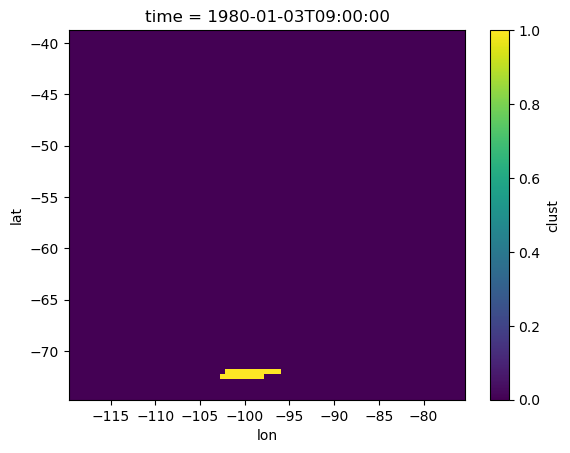

In [120]:
storm_da_ais.sel(time=first_landfall).plot()

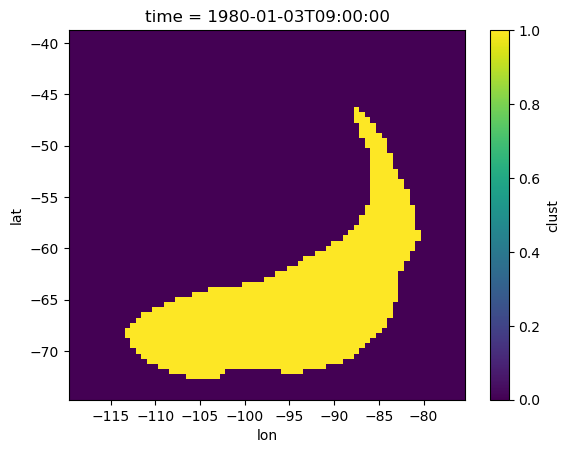

In [121]:
storm_da_ocean.sel(time=first_landfall).plot()

In [132]:
def compute_max_SLPgrad(storm_da, var_da, area_da, ais_da):

    storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
    storm_ocean_mask = np.logical_not(storm_ais_mask)
    storm_da_ais = storm_da.where(storm_ais_mask, 0)
    storm_da_ocean = storm_da.where(storm_ocean_mask, 0)

    var_da_subset = var_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)

    var_da_subset_landfall = var_da_subset.sel(time=first_landfall)
    storm_da_ocean_landfall = storm_da_ocean.sel(time=first_landfall)

    # return -1 if no points over the ocean at first landfalling time
    if (storm_da_ocean_landfall == 0).all().values:
        return -1
    ## compute pressure gradient
    # convert to radians
    rads = var_da_subset_landfall.assign_coords(lon=np.radians(var_da_subset_landfall.lon), lat=np.radians(var_da_subset_landfall.lat))
    # partials in the latitude direction (spherical coordinates)
    r = 6378 # radius of Earth in km
    lat_partials = rads.differentiate('lat')/r
    # partials in the longitudinal direction (spherical coordinates)
    lon_partials = rads.differentiate('lon')/(np.sin(rads.lat)*r)
    
    magnitude = np.sqrt(lon_partials**2 + lat_partials**2)
    max_grad = np.max(magnitude.values*storm_da_ocean_landfall.values)

    return max_grad

In [137]:

compute_max_SLPgrad(storm_da, variable_da, cell_areas, ais_mask)

7.06 ms ± 62.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [138]:
dat = xr.open_dataset('/pscratch/sd/j/jbbutler/merra2_data_850hPa_wind/M2T1NXSLV.5.12.4:MERRA2_300.tavg1_2d_slv_Nx.20080824.nc4.nc4')

In [140]:
dat['V850']

<xarray.DataArray 'V850' (time: 24, lat: 95, lon: 576)> Size: 5MB
[1313280 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 192B 2008-08-24T00:30:00 ... 2008-08-24T23...
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
Attributes:
    long_name:       northward_wind_at_850_hPa
    units:           m s-1
    fmissing_value:  1000000000000000.0
    standard_name:   northward_wind_at_850_hPa
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]

In [143]:
def compute_avg_landfalling_wind(storm_da, var_da, area_da, ais_da):

    storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
    storm_da_ais = storm_da.where(storm_ais_mask, 0)
    first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)

    var_da_subset = var_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    storm_cell_areas = area_da.sel(lat=storm_da.lat, lon=storm_da.lon)
    tot_area = storm_da.dot(storm_cell_areas)
    first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)
    avg_wind = (storm_cell_areas.dot(storm_da*var_da_subset)/tot_area).sel(time=first_landfall)

    return avg_wind

In [144]:
compute_avg_landfalling_wind(storm_da, variable_da, cell_areas, ais_mask)

<xarray.DataArray ()> Size: 8B
array(98064.27834118)
Coordinates:
    time     datetime64[ns] 8B 1980-01-03T09:00:00

In [146]:
res = landfalling_storms.iloc[0:10]

In [152]:
from pathlib import Path
import os

In [154]:
home_dir = str(Path(os.getcwd()).parents[1])
scratch_path = '/pscratch/sd/j/jbbutler/'
inst1_data_path = '/pscratch/sd/j/jbbutler/merra2_data_T2m_V10m_SLP_IWV/'
tavg1_precip_data_path = '/pscratch/sd/j/jbbutler/merra2_data_precip_ivt/'
tavg1_850hPa_wind_data_path = '/pscratch/sd/j/jbbutler/merra2_data_precip_ivt/'

# load up all of the dataframes
df_path = home_dir + '/data/ar_database/dataframe_eps12_eps500_minpts5_reppts20/storm_df.h5'
dataframe = pd.read_hdf(df_path)

In [242]:
dat = pd.read_hdf('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts20/landfalling_storm_quantities_df.h5')

In [243]:
dat[dat.columns[1:]]

,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,...,max_ocean_SLP_gradient,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais,max_landfalling_v850hPa,avg_landfalling_v850hPa
cluster,,,,,,,,,,,,,,,,,,,,,
1.0,True,1.906981e+06,1.688673e+06,1.423480e+04,2.669025e+04,1 days 21:00:00,1980-01-02 00:00:00,1980-01-03 18:00:00,-74.5,273.484894,...,4.899358,4.733398,185.946506,278.429169,446.299878,1057.458008,9.535485e+09,4.794091e+11,26.413338,17.157453375424755
3.0,True,1.755660e+06,1.348961e+06,1.901187e+05,3.327078e+05,1 days 21:00:00,1980-01-06 18:00:00,1980-01-08 12:00:00,-74.0,275.100708,...,5.984890,9.100540,54.481882,236.822678,390.791530,800.904724,1.429101e+11,6.217644e+12,27.332188,16.166067475829013
4.0,True,8.338254e+04,8.338254e+04,8.338254e+04,1.042282e+04,0 days 03:00:00,1980-01-08 12:00:00,1980-01-08 12:00:00,-79.5,264.712708,...,-1.000000,7.766602,12.747105,24.080845,12.747105,24.080845,0.000000e+00,2.451068e+10,-1.0,-1
5.0,True,1.429139e+06,1.429139e+06,1.429139e+06,1.786424e+05,0 days 03:00:00,1980-01-09 15:00:00,1980-01-09 15:00:00,-83.5,265.511627,...,-1.000000,11.666794,16.818335,37.604511,16.818335,37.604511,0.000000e+00,1.090766e+12,-1.0,-1
11.0,True,7.357497e+05,7.008839e+05,2.107631e+05,5.269078e+04,0 days 06:00:00,1980-01-11 12:00:00,1980-01-11 15:00:00,-85.0,271.994690,...,2.867155,4.731720,93.240500,178.436508,199.695713,342.896973,1.486646e+10,1.066740e+12,23.885662,18.191478570352803
12.0,True,1.466806e+06,1.207427e+06,1.197884e+05,1.497355e+05,1 days 09:00:00,1980-01-12 03:00:00,1980-01-13 09:00:00,-85.0,273.430054,...,4.138897,8.239502,94.095276,203.303299,429.014316,1215.852417,2.441953e+10,2.718185e+12,27.479479,16.801240286072247
13.0,True,2.564244e+06,1.901876e+06,1.069995e+06,1.604993e+06,2 days 00:00:00,1980-01-14 12:00:00,1980-01-16 09:00:00,-85.0,275.629974,...,3.984146,12.359955,49.961331,358.498505,155.453791,852.707825,3.473608e+11,1.410684e+13,24.461037,15.046944413046763
14.0,True,1.919207e+06,1.661710e+06,9.800287e+02,8.575251e+02,0 days 21:00:00,1980-01-17 06:00:00,1980-01-18 00:00:00,-69.5,270.711212,...,4.265896,3.037811,91.888767,99.342796,453.854870,974.522827,5.040665e+06,6.909397e+10,26.422926,16.429629327472096
15.0,True,2.525372e+06,1.772728e+06,2.131544e+05,5.328859e+05,2 days 12:00:00,1980-01-17 09:00:00,1980-01-19 18:00:00,-85.0,273.436768,...,3.767812,8.477936,35.498314,151.048309,289.514385,1187.149292,2.668028e+09,2.377427e+12,25.958397,14.84312466035306


In [ ]:
storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
storm_ocean_mask = np.logical_not(storm_ais_mask)
storm_da_ais = storm_da.where(storm_ais_mask, 0)
storm_da_ocean = storm_da.where(storm_ocean_mask, 0)
first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)

storm_da_ocean_landfall = storm_da_ocean.sel(time=first_landfall)
if (storm_da_ocean_landfall == 0).all().values:
        return -1

var_da_subset = var_da.sel(lat=storm_da.lat, lon=storm_da.lon)
# for some reason, 850hPa wind is null for values in and around the AIS
# so, we compute over the ocean, where the 850hPa wind is also not null
notnull = var_da_subset.notnull()
storm_da_ocean_notnull = storm_da_ocean*notnull
storm_cell_areas = area_da.sel(lat=storm_da.lat, lon=storm_da.lon)
tot_area = storm_da_ocean_notnull.dot(storm_cell_areas)
    
avg_wind = (storm_cell_areas.dot(storm_da_ocean_notnull*var_da_subset)/tot_area).sel(time=first_landfall).values

In [225]:
storm_da = storm_ex.data_array

In [226]:
storm_ais_mask = ais_mask.sel(lat=storm_da.lat, lon=storm_da.lon).Zwallybasins
storm_ocean_mask = np.logical_not(storm_ais_mask)
storm_da_ais = storm_da.where(storm_ais_mask, 0)
storm_da_ocean = storm_da.where(storm_ocean_mask, 0)
first_landfall = np.min(storm_da.time[storm_da_ais.any(dim=['lat', 'lon'])].values)

In [227]:
storm_da_ocean_landfall = storm_da_ocean.sel(time=first_landfall)

In [238]:
var_da_subset = variable_da.sel(lat=storm_da.lat, lon=storm_da.lon)
var_da_subset = var_da_subset.fillna(0)

In [239]:
notnull = var_da_subset.notnull()
storm_da_ocean_notnull = storm_da_ocean*notnull
storm_cell_areas = cell_areas.sel(lat=storm_da.lat, lon=storm_da.lon)
tot_area = storm_da_ocean_notnull.dot(storm_cell_areas)

In [240]:
avg_wind = (storm_cell_areas.dot(storm_da_ocean_notnull*var_da_subset)/tot_area).sel(time=first_landfall).values

In [241]:
avg_wind

array(-16.16606748)

In [234]:
storm_da_ocean_notnull*var_da_subset

<xarray.DataArray (time: 14, lat: 71, lon: 85)> Size: 338kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 112B 1980-01-06T18:00:00 ... 1980-01-08T12...
  * lat      (lat) float64 568B -74.0 -73.5 -73.0 -72.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 680B 92.5 93.12 93.75 94.38 ... 143.8 144.4 145.0

In [289]:
desired_dates = pd.date_range(start='1/1/1980', end='12/31/2022', )

In [299]:
dates = os.listdir('/pscratch/sd/j/jbbutler/merra2_data_850hPa_wind/')
dates = [fname.split('.')[1] for fname in dates]
dates = np.sort(np.array(dates))[0:len(dates)-8]
dates=pd.to_datetime(dates)

In [300]:
for date in desired_dates:
    if date not in dates:
        print(date)

In [301]:
dataset = pd.read_hdf('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts20/landfalling_storm_quantities_df.h5')

In [309]:
dataset.columns

Index(['data_array', 'is_landfalling', 'max_area', 'mean_area',
       'mean_landfalling_area', 'cumulative_landfalling_area', 'duration',
       'start_date', 'end_date', 'max_south_extent', 'max_T2m_ais',
       'avg_V10m_ais', 'max_V10m_ais', 'avg_IWV_ais', 'max_IWV_ais', 'avg_IWV',
       'max_IWV', 'min_ocean_SLP', 'max_ocean_SLP_gradient',
       'max_T2M_anomaly_ais', 'avg_vIVT_ais', 'max_vIVT_ais', 'avg_vIVT',
       'max_vIVT', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais',
       'max_landfalling_v850hPa', 'avg_landfalling_v850hPa'],
      dtype='object')

In [310]:
dataset.loc[dataset.max_ocean_SLP_gradient.idxmax()].data_array

<xarray.DataArray 'clust' (time: 6, lat: 62, lon: 76)> Size: 28kB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int8)
Coordinates:
  * time     (time) datetime64[ns] 48B 2019-09-02T06:00:00 ... 2019-09-02T21:...
  * lat      (lat) float64 496B -75.0 -74.5 -74.0 -73.5 ... -45.5 -45.0 -44.5
  * lon      (lon) float64 608B 37.5 38.75 39.38 40.0 ... 83.12 83.75 84.38 85.0